In [75]:
import pandas as pd
import numpy as np
import kagglehub
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR

# Загрузка данных

In [76]:
os.environ["KAGGLEHUB_CACHE"] = "data/kagglehub_cache"

path = kagglehub.dataset_download(
    "burakergene/life-expectancy"
)

print("Dataset path:", path)

df = pd.read_csv(path + "/Life_Expectancy_Data.csv")

print(df.head())
print(df.info())
print(df.describe())
duplicates_count = df.duplicated().sum()
print(f"\nКоличество дубликатов: {duplicates_count}")

Dataset path: data/kagglehub_cache\datasets\burakergene\life-expectancy\versions\3
       Country  Year      Status  Life expectancy   Adult Mortality  \
0  Afghanistan  2015  Developing              65.0              263   
1  Afghanistan  2014  Developing              59.9              271   
2  Afghanistan  2013  Developing              59.9              268   
3  Afghanistan  2012  Developing              59.5              272   
4  Afghanistan  2011  Developing              59.2              275   

   infant deaths  Alcohol  percentage expenditure  Hepatitis B  Measles   ...  \
0             62     0.01               71.279624           65      1154  ...   
1             64     0.01               73.523582           62       492  ...   
2             66     0.01               73.219243           64       430  ...   
3             69     0.01               78.184215           67      2787  ...   
4             71     0.01                7.097109           68      3013  ...   

   

# Визуализация данных

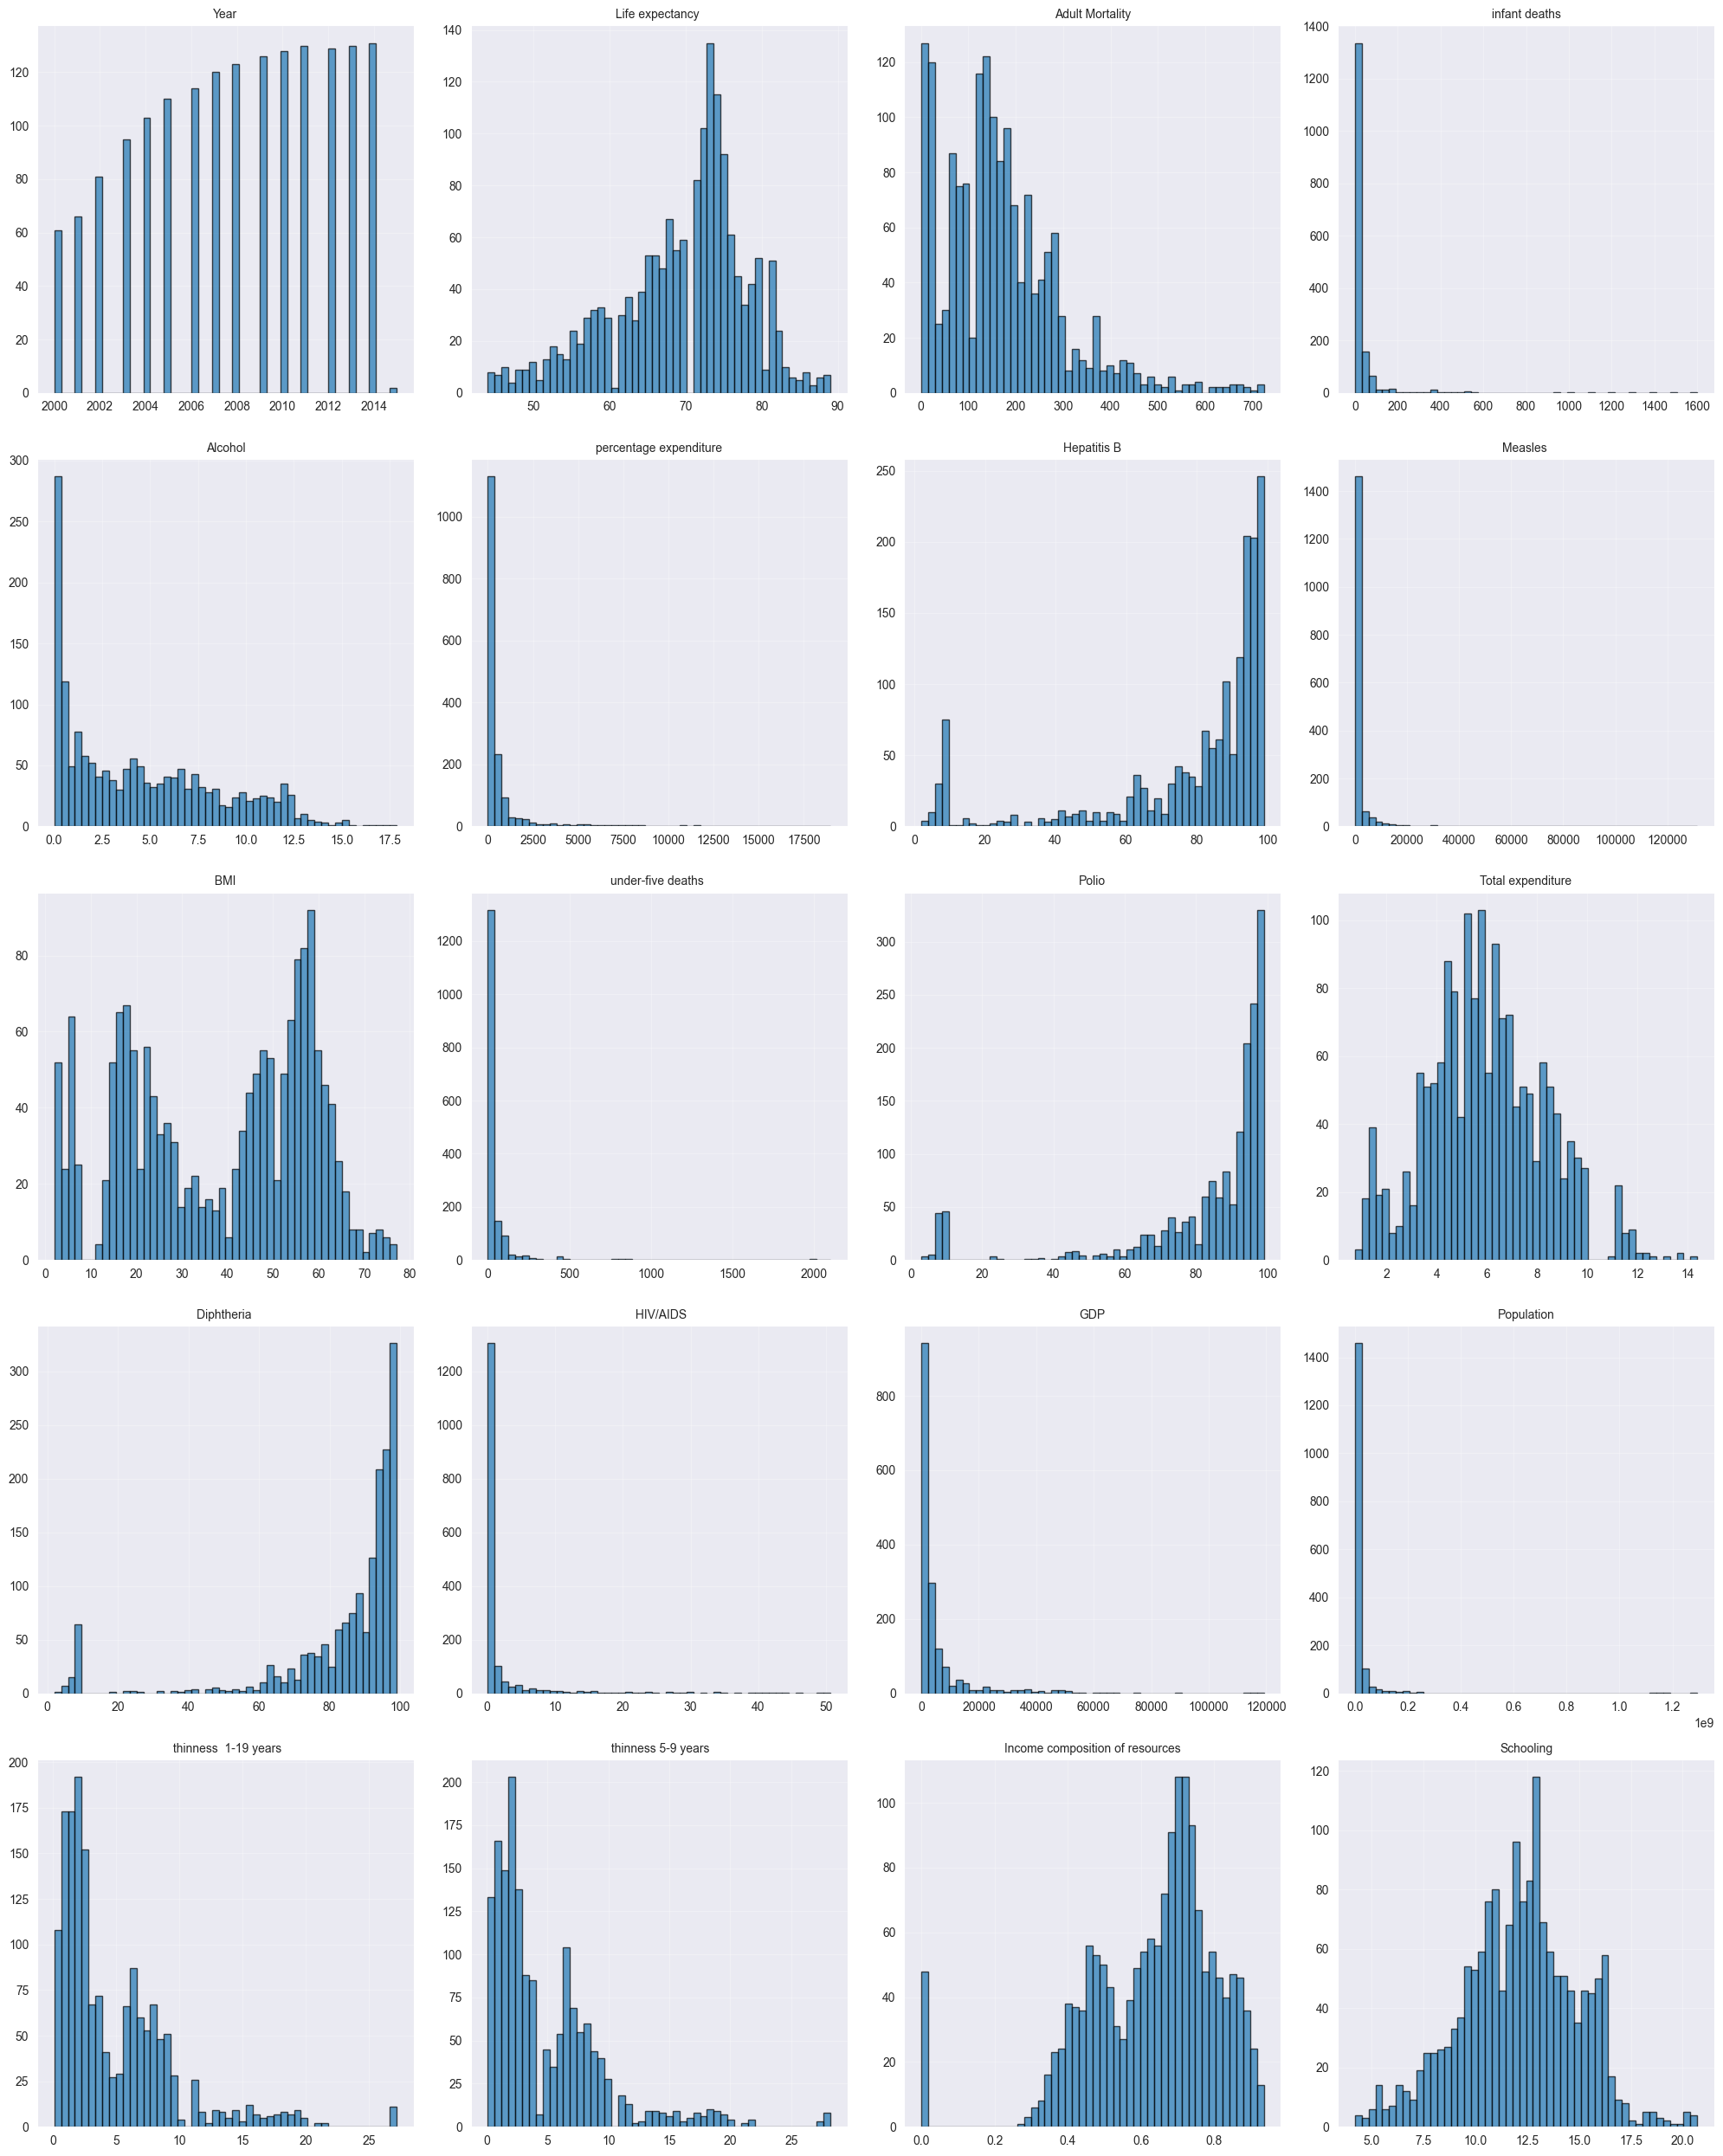

In [77]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
n_cols = 4
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.ravel()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=50, alpha=0.7, edgecolor='black')
    axes[i].set_title(f'{col}', fontsize=10)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Анализ корреляции признаков
Корреляция с целевой колонкой

ТОП-10 корреляций с Life expectancy:
Life expectancy                    1.000000
Schooling                          0.727630
Income composition of resources    0.721083
Adult Mortality                    0.702523
HIV/AIDS                           0.592236
BMI                                0.542042
thinness  1-19 years               0.457838
thinness 5-9 years                 0.457508
GDP                                0.441322
percentage expenditure             0.409631
Name: Life expectancy, dtype: float64


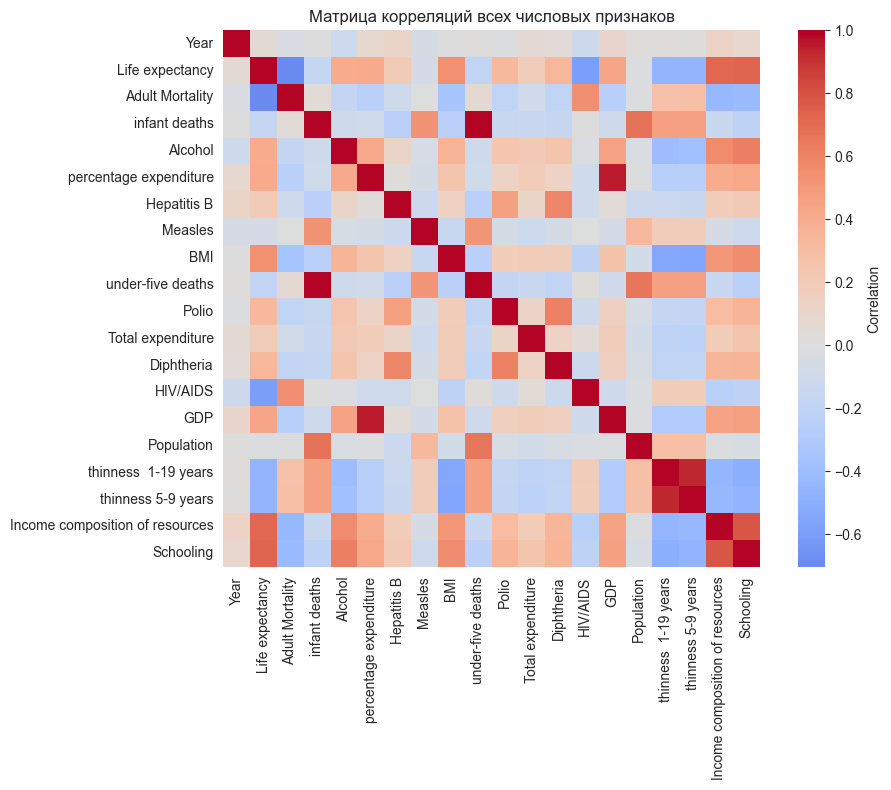

In [78]:
df.columns = df.columns.str.strip()

target = "Life expectancy"
numeric_df = df.select_dtypes(include=[np.number])

target_corr = numeric_df.corr()[target].abs().sort_values(ascending=False)
print("ТОП-10 корреляций с Life expectancy:")
print(target_corr.head(10))

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm', center=0,
            square=True, cbar_kws={'label': 'Correlation'})
plt.title('Матрица корреляций всех числовых признаков')
plt.tight_layout()
plt.show()

Взаимные корреляции признаков

In [79]:
corr_matrix = numeric_df.corr()
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.9:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_val
            ))

print("Пары с высокой корреляцией")
for feat1, feat2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
    print(f"{feat1:25} - {feat2:25} = {corr:.4f}")

Пары с высокой корреляцией
under-five deaths         - infant deaths             = 0.9969
GDP                       - percentage expenditure    = 0.9593
thinness 5-9 years        - thinness  1-19 years      = 0.9279


# Подготовка выборок

In [80]:
target_col = "Life expectancy"
exclude_cols = [target_col]

feature_cols = [col for col in df.columns if col not in exclude_cols]
print("Все признаки до очистки:", feature_cols)
print(f"Количество признаков до очистки: {len(feature_cols)}")

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, random_state=42, shuffle=True
)

# Числовые и категориальные признаки (без 3 сильно коррелированных признаков)
numeric_features = [
    'Year', 'Adult Mortality', 'Alcohol',
    'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure',
    'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years',
    'Income composition of resources', 'Schooling'
]

categorical_features = ['Country', 'Status']

print(f"\nЧисловых признаков: {len(numeric_features)}")
print(f"Категорий категориальных: {len(categorical_features)}")

Все признаки до очистки: ['Country', 'Year', 'Status', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling']
Количество признаков до очистки: 21

Числовых признаков: 16
Категорий категориальных: 2


# Предобработка данных

In [81]:
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ]
)

# SMAPE

In [82]:
def smape(y_true, y_pred):
    denominator = np.abs(y_true) + np.abs(y_pred)
    diff = np.abs(y_true - y_pred) * 2
    mask = denominator != 0
    return 100 * np.mean(diff[mask] / denominator[mask])

# Линейная регрессия
Модель

In [83]:
lin_reg = LinearRegression()

pipe_lin = Pipeline([
    ('preprocessor', preprocessor),
    ('lin_reg', lin_reg)
])

Обучение

In [84]:
pipe_lin.fit(X_train, y_train)
y_pred_lin = pipe_lin.predict(X_test)

rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
r2_lin = r2_score(y_test, y_pred_lin)
smape_lin = smape(y_test, y_pred_lin)

print(f"\nЛИНЕЙНАЯ РЕГРЕССИЯ РЕЗУЛЬТАТЫ:")
print(f"RMSE: {rmse_lin:.3f} лет")
print(f"R2:   {r2_lin:.4f}")
print(f"SMAPE: {smape_lin:.2f}%")


ЛИНЕЙНАЯ РЕГРЕССИЯ РЕЗУЛЬТАТЫ:
RMSE: 1.950 лет
R2:   0.9465
SMAPE: 1.67%


Визуализация

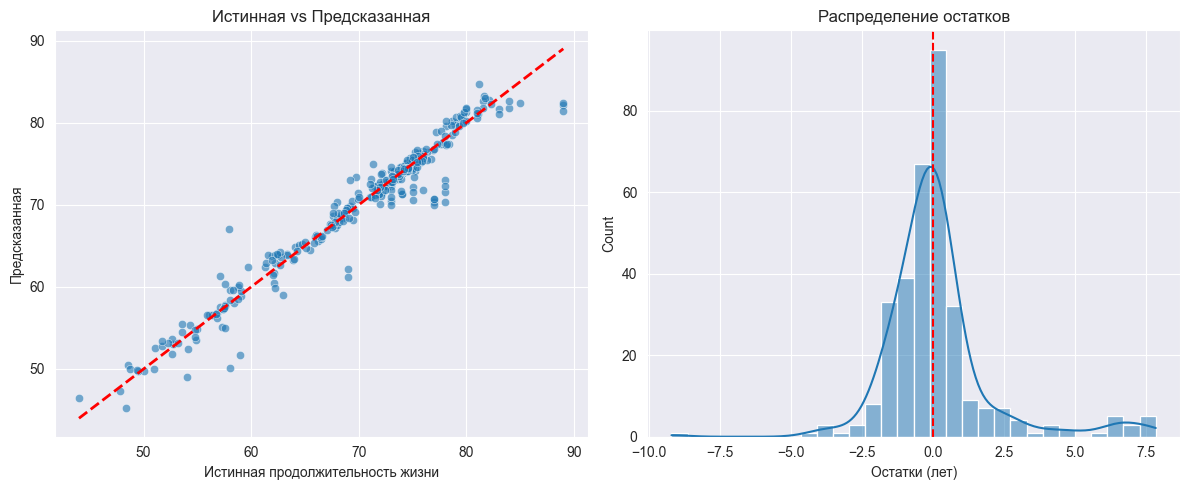

In [85]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_lin, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Истинная продолжительность жизни")
plt.ylabel("Предсказанная")
plt.title("Истинная vs Предсказанная")

plt.subplot(1, 2, 2)
residuals = y_test - y_pred_lin
sns.histplot(residuals, kde=True, bins=30)
plt.xlabel("Остатки (лет)")
plt.title("Распределение остатков")
plt.axvline(0, color='red', linestyle='--')

plt.tight_layout()
plt.show()

# Полиномиальная регрессия
Модель

In [86]:
poly_reg = Pipeline([
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lin_reg', LinearRegression())
])

Обучение

In [87]:
poly_reg.fit(X_train, y_train)
y_pred_poly = poly_reg.predict(X_test)

rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)
smape_poly = smape(y_test, y_pred_poly)

print(f"\nПОЛИНОМИАЛЬНАЯ РЕГРЕССИЯ (deg=2) РЕЗУЛЬТАТЫ:")
print(f"RMSE: {rmse_poly:.3f} лет")
print(f"R2:   {r2_poly:.4f}")
print(f"SMAPE: {smape_poly:.2f}%")


ПОЛИНОМИАЛЬНАЯ РЕГРЕССИЯ (deg=2) РЕЗУЛЬТАТЫ:
RMSE: 31.937 лет
R2:   -13.3612
SMAPE: 11.52%


Визуализация

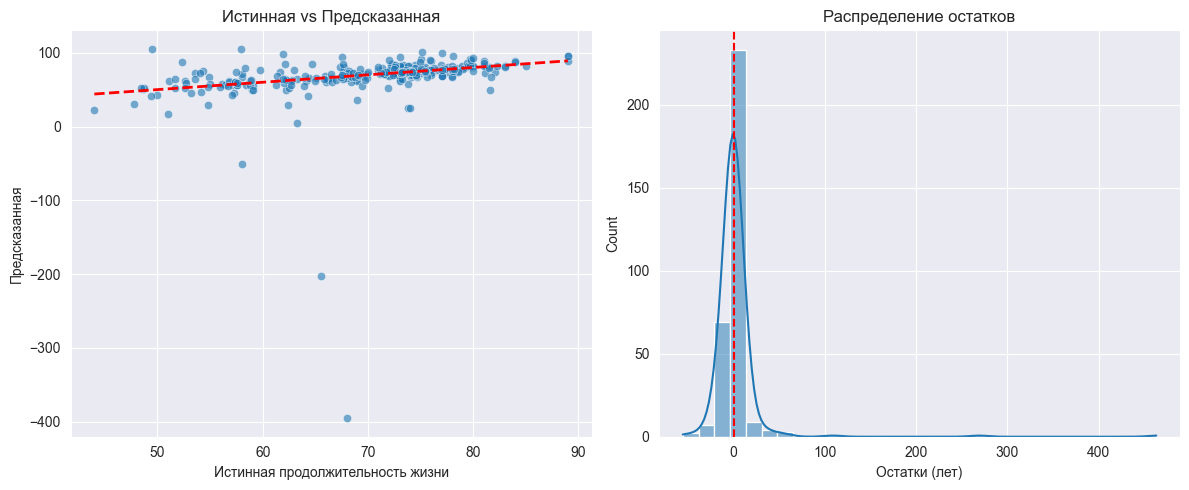

In [88]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_poly, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Истинная продолжительность жизни")
plt.ylabel("Предсказанная")
plt.title("Истинная vs Предсказанная")

plt.subplot(1, 2, 2)
residuals = y_test - y_pred_poly
sns.histplot(residuals, kde=True, bins=30)
plt.xlabel("Остатки (лет)")
plt.title("Распределение остатков")
plt.axvline(0, color='red', linestyle='--')

plt.tight_layout()
plt.show()


# Support Vector Machine
Модель

In [89]:
svm_reg = SVR(
    kernel='rbf',
    C=10.0,
    epsilon=0.1
)

pipe_svm = Pipeline([
    ('preprocessor', preprocessor),
    ('svm', svm_reg)
])

Обучение

In [90]:
pipe_svm.fit(X_train, y_train)
y_pred_svm = pipe_svm.predict(X_test)

rmse_svm = np.sqrt(mean_squared_error(y_test, y_pred_svm))
r2_svm = r2_score(y_test, y_pred_svm)
smape_svm = smape(y_test, y_pred_svm)

print(f"\nSVM (SVR RBF) РЕЗУЛЬТАТЫ:")
print(f"RMSE: {rmse_svm:.3f} лет")
print(f"R2:   {r2_svm:.4f}")
print(f"SMAPE: {smape_svm:.2f}%")


SVM (SVR RBF) РЕЗУЛЬТАТЫ:
RMSE: 2.001 лет
R2:   0.9436
SMAPE: 1.64%


Визуализация

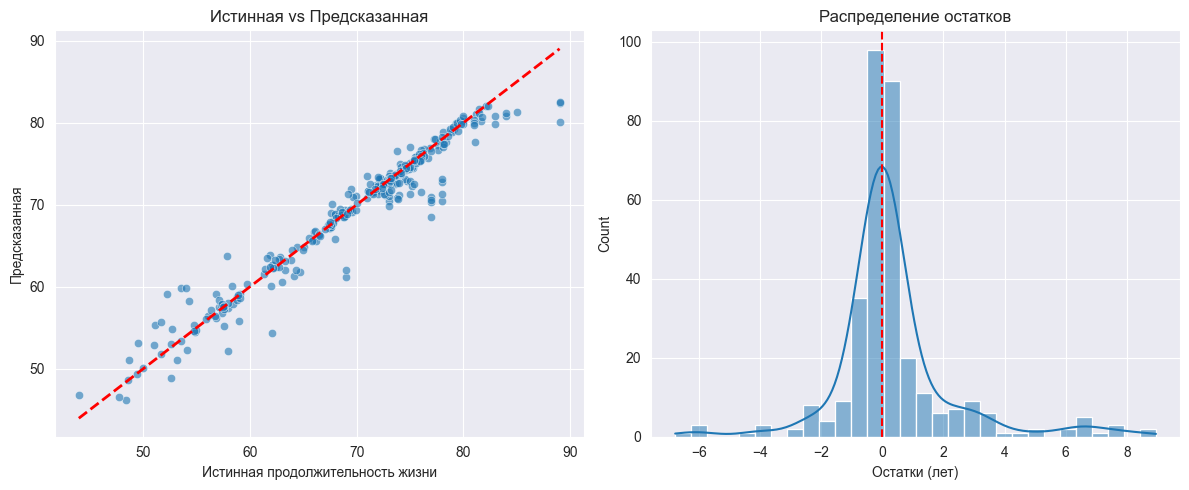

In [91]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_svm, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Истинная продолжительность жизни")
plt.ylabel("Предсказанная")
plt.title("Истинная vs Предсказанная")

plt.subplot(1, 2, 2)
residuals = y_test - y_pred_svm
sns.histplot(residuals, kde=True, bins=30)
plt.xlabel("Остатки (лет)")
plt.title("Распределение остатков")
plt.axvline(0, color='red', linestyle='--')

plt.tight_layout()
plt.show()

# Random Forest
Модель

In [92]:
pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('rf', RandomForestRegressor(
        n_estimators=150,
        max_depth=10,
        min_samples_split=40,
        min_samples_leaf=20,
        random_state=42
    ))
])

Обучение

In [93]:
pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
smape_rf = smape(y_test, y_pred_rf)

print(f'RMSE: {rmse_rf:.2f}')
print(f'R2: {r2_rf:.4f}')
print(f"SMAPE: {smape_rf:.2f}%")

RMSE: 2.36
R2: 0.9218
SMAPE: 2.32%


Визуализация

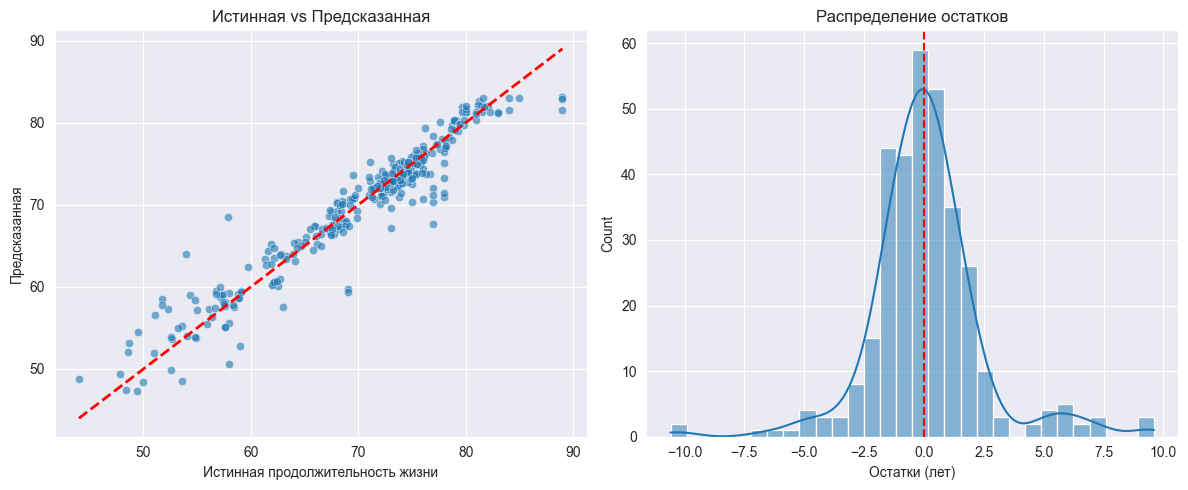

In [94]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Истинная продолжительность жизни")
plt.ylabel("Предсказанная")
plt.title("Истинная vs Предсказанная")

plt.subplot(1, 2, 2)
residuals = y_test - y_pred_rf
sns.histplot(residuals, kde=True, bins=30)
plt.xlabel("Остатки (лет)")
plt.title("Распределение остатков")
plt.axvline(0, color='red', linestyle='--')

plt.tight_layout()
plt.show()


# Gradient Boosting on Decision Tree
Модель

In [95]:
gbdt = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_depth=6,
    max_iter=200,
    min_samples_leaf=20,
    l2_regularization=1.0,
    random_state=42,
    early_stopping=True
)

pipe_gbdt = Pipeline([
    ('preprocessor', preprocessor),
    ('gbdt', gbdt)
])

Обучение + метрики

In [96]:
pipe_gbdt.fit(X_train, y_train)
y_pred_gbdt = pipe_gbdt.predict(X_test)

rmse_gbdt = np.sqrt(mean_squared_error(y_test, y_pred_gbdt))
r2_gbdt = r2_score(y_test, y_pred_gbdt)
smape_gbdt = smape(y_test, y_pred_gbdt)

print(f"\nGBDT РЕЗУЛЬТАТЫ:")
print(f"RMSE: {rmse_gbdt:.3f} лет")
print(f"R2:   {r2_gbdt:.4f}")
print(f"SMAPE: {smape_gbdt:.2f}%")


GBDT РЕЗУЛЬТАТЫ:
RMSE: 2.092 лет
R2:   0.9384
SMAPE: 1.93%


Визуализация

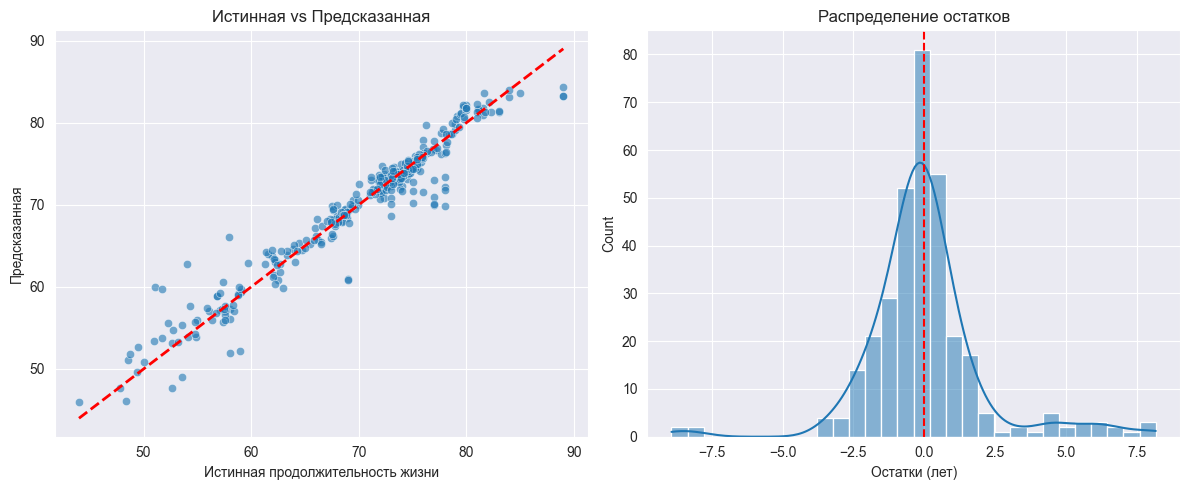

In [97]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_gbdt, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Истинная продолжительность жизни")
plt.ylabel("Предсказанная")
plt.title("Истинная vs Предсказанная")

plt.subplot(1, 2, 2)
residuals = y_test - y_pred_gbdt
sns.histplot(residuals, kde=True, bins=30)
plt.xlabel("Остатки (лет)")
plt.title("Распределение остатков")
plt.axvline(0, color='red', linestyle='--')

plt.tight_layout()
plt.show()


# Ридж-регрессия

Подготовка выборок без ручной очистик

In [98]:
target_col = "Life expectancy"
exclude_cols = [target_col]

feature_cols = [col for col in df.columns if col not in exclude_cols]
print("Все признаки до очистки:", feature_cols)
print(f"Количество признаков с целевым: {len(feature_cols)}")

X_ridge = df[feature_cols]
y_ridge = df[target_col]

X_train_ridge, X_test_ridge, y_train_ridge, y_test_ridge = train_test_split(
    X_ridge, y_ridge, train_size=0.8, random_state=42, shuffle=True
)

# Числовые и категориальные признаки
numeric_features = [
    'Year', 'Adult Mortality', 'Alcohol', 'thinness 5-9 years', 'percentage expenditure', 'infant deaths'
    'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure',
    'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years',
    'Income composition of resources', 'Schooling'
]

categorical_features = ['Country', 'Status']

print(f"\nЧисловых признаков: {len(numeric_features)}")
print(f"Категорий категориальных: {len(categorical_features)}")

Все признаки до очистки: ['Country', 'Year', 'Status', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling']
Количество признаков с целевым: 21

Числовых признаков: 18
Категорий категориальных: 2


Модель

In [99]:
ridge = Ridge(alpha=1.0, random_state=42)

pipe_ridge = Pipeline([
    ('preprocessor', preprocessor),
    ('ridge', ridge)
])

Обучение

In [100]:
pipe_ridge.fit(X_train_ridge, y_train_ridge)
y_pred_ridge = pipe_ridge.predict(X_test_ridge)

rmse_ridge = np.sqrt(mean_squared_error(y_test_ridge, y_pred_ridge))
r2_ridge = r2_score(y_test_ridge, y_pred_ridge)
smape_ridge = smape(y_test_ridge, y_pred_ridge)

print(f"\nРИДЖ-РЕГРЕССИЯ РЕЗУЛЬТАТЫ:")
print(f"RMSE: {rmse_ridge:.3f} лет")
print(f"R2:   {r2_ridge:.4f}")
print(f"SMAPE: {smape_ridge:.2f}%")


РИДЖ-РЕГРЕССИЯ РЕЗУЛЬТАТЫ:
RMSE: 2.108 лет
R2:   0.9374
SMAPE: 2.00%


Визуализация

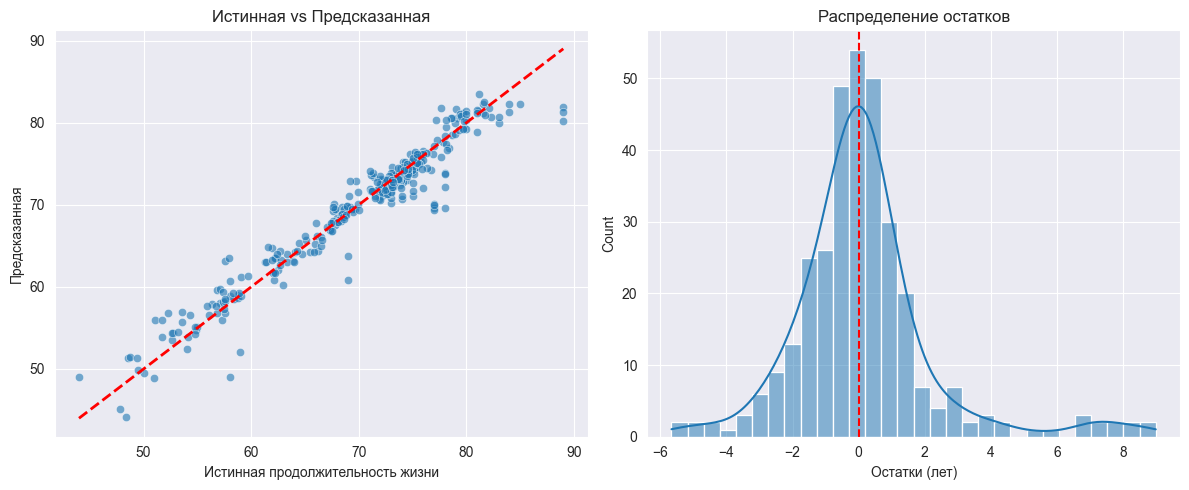

In [101]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test_ridge, y=y_pred_ridge, alpha=0.6)
plt.plot([y_test_ridge.min(), y_test_ridge.max()], [y_test_ridge.min(), y_test_ridge.max()], 'r--', lw=2)
plt.xlabel("Истинная продолжительность жизни")
plt.ylabel("Предсказанная")
plt.title("Истинная vs Предсказанная")

plt.subplot(1, 2, 2)
residuals = y_test_ridge - y_pred_ridge
sns.histplot(residuals, kde=True, bins=30)
plt.xlabel("Остатки (лет)")
plt.title("Распределение остатков")
plt.axvline(0, color='red', linestyle='--')

plt.tight_layout()
plt.show()
